## Group 2 ML Project: Predicting Oil Price in light of the Iran war

In [86]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, classification_report, recall_score,accuracy_score, precision_score, f1_score,confusion_matrix

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_excel('/content/Merged.xlsx')
display(df.head())

print("Dataset Info:")
print(df.info())

print("\nSummary Statistics:")
display(df.describe())

print("\nMissing Values per Column:")
display(df.isnull().sum())

,WEEK (acled),Total_Events,Fatalities,Battles_Events,Explosions_Events,Strategic_Events,Bahrain_Events,Iran_Events,Iraq_Events,Israel_Events,...,defense_stocks,sp500_etf,energy_stocks,oil_volatility,market_volatility,observation_date (waad),FEDFUNDS,Date,US_Crude_Inventories_mb,OPEC_Production_mbpd
0,2022-01-01,514,454,93,296,125,0,3,75,3,...,101.616533,443.675336,25.423856,39.080000,18.322,2022-01-02,0.08,2022-01-07,415574.5,32132.651452
1,2022-01-08,570,468,95,363,112,0,2,96,3,...,102.938904,439.508984,26.946074,36.928001,18.986,2022-01-09,0.08,2022-01-14,413813.0,32132.651452
2,2022-01-15,472,740,97,281,94,0,0,52,1,...,100.821365,421.759918,27.268082,42.187500,25.270,2022-01-16,0.08,2022-01-21,416190.0,32132.651452
3,2022-01-22,512,617,154,260,98,0,0,74,2,...,97.312057,410.406329,27.770855,47.156001,30.234,2022-01-23,0.08,2022-01-28,415143.0,32132.651452
4,2022-01-29,479,553,96,267,116,3,1,77,0,...,98.532274,424.450476,29.010172,42.310001,23.290,2022-01-30,0.08,2022-02-04,412765.0,32985.541464


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   WEEK (acled)                     236 non-null    datetime64[ns]
 1   Total_Events                     236 non-null    int64         
 2   Fatalities                       236 non-null    int64         
 3   Battles_Events                   236 non-null    int64         
 4   Explosions_Events                236 non-null    int64         
 5   Strategic_Events                 236 non-null    int64         
 6   Bahrain_Events                   236 non-null    int64         
 7   Iran_Events                      236 non-null    int64         
 8   Iraq_Events                      236 non-null    int64         
 9   Israel_Events                    236 non-null    int64         
 10  Jordan_Events                    236 non-null   

,WEEK (acled),Total_Events,Fatalities,Battles_Events,Explosions_Events,Strategic_Events,Bahrain_Events,Iran_Events,Iraq_Events,Israel_Events,...,defense_stocks,sp500_etf,energy_stocks,oil_volatility,market_volatility,observation_date (waad),FEDFUNDS,Date,US_Crude_Inventories_mb,OPEC_Production_mbpd
count,236,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000,...,236.000000,236.000000,236.000000,236.000000,236.000000,236,236.000000,236,236.000000,236.000000
mean,2024-04-02 12:00:00,741.694915,517.313559,127.224576,442.500000,171.970339,1.072034,22.012712,105.677966,33.127119,...,143.797851,510.177370,41.005977,41.825896,19.228042,2024-04-03 12:00:00,3.957500,2024-04-08 12:00:00,433619.489407,32453.542506
min,2022-01-01 00:00:00,276.000000,64.000000,37.000000,75.000000,67.000000,0.000000,0.000000,15.000000,0.000000,...,89.803053,342.256787,25.423856,24.028000,12.200000,2022-01-02 00:00:00,0.080000,2022-01-07 00:00:00,408359.000000,25080.244857
25%,2023-02-16 06:00:00,475.750000,178.750000,82.750000,205.750000,115.750000,0.000000,2.000000,62.000000,2.000000,...,107.951897,404.611172,37.764153,32.785000,15.496625,2023-02-17 06:00:00,3.640000,2023-02-22 06:00:00,419830.750000,32541.118364
50%,2024-04-02 12:00:00,600.000000,336.000000,129.000000,320.500000,151.500000,0.000000,3.000000,106.000000,5.000000,...,127.339789,500.833795,40.564054,37.399750,17.933000,2024-04-03 12:00:00,4.330000,2024-04-08 12:00:00,428053.000000,32806.439933
75%,2025-05-18 18:00:00,975.750000,704.000000,159.000000,654.250000,214.250000,0.000000,6.000000,144.000000,48.500000,...,171.794337,592.911191,43.150196,47.634500,22.129750,2025-05-19 18:00:00,5.130000,2025-05-24 18:00:00,445033.750000,33335.181156
max,2026-07-04 00:00:00,2096.000000,3326.000000,331.000000,1526.000000,507.000000,36.000000,612.000000,245.000000,254.000000,...,244.623395,751.462061,60.587061,113.774001,42.242001,2026-07-05 00:00:00,5.330000,2026-07-10 00:00:00,481180.000000,35431.258171
std,NaN,376.731814,522.338493,51.873377,320.782308,78.060718,4.582936,89.103167,50.425995,55.366254,...,44.962393,115.917373,6.511356,13.613774,5.237002,NaN,1.513211,NaN,17374.439023,2303.898124



Missing Values per Column:


,0
WEEK (acled),0
Total_Events,0
Fatalities,0
Battles_Events,0
Explosions_Events,0
Strategic_Events,0
Bahrain_Events,0
Iran_Events,0
Iraq_Events,0
Israel_Events,0


We had to merge all data into weekly intervals to be able to unify and predict next week average.

**ACLED Geopolitical Data:**
* **WEEK (acled):** Starting date of aggregated geopolitical weekly events.
* **Total_Events:** Sum of Battles, Explosions, and Strategic events for the week.
* **Fatalities:** Count of fatalities.
* **Battles_Events, Explosions_Events, Strategic_Events:** Specific types of conflict event counts.
* **Country_Events (Bahrain to Yemen):** Total events recorded for each specific country; their sum equals `Total_Events`.

**GDELT Media Data:**
* **week_start, week_range(gdelt):** Date columns from the GDELT source.
* **total_geopolitical_event_volume:** Volume of events in global news.
* **average_media_sentiment:** The average tone of media coverage.
* **geopolitical_instability_score:** Calculated score for regional stability.
* **media_panic_amplification:** Measure of media focus on crisis.
* **kinetic_warfare, economic_coercion, diplomatic_threats:** Specific volumes of conflict types identified via media analysis.

**Yahoo Finance Data:**
* **start_date, end_date, date_range:** Date columns from Yahoo Finance.
* **target_brent_price:** Global benchmark for crude oil (Primary Target).
* **wti_price:** American domestic oil benchmark.
* **usd_index:** U.S. Dollar value (typically inverse to commodity prices).
* **gold_price:** Global safe-haven asset (Secondary Target).
* **defense_stocks (ITA):** ETF tracking aerospace and defense companies.
* **sp500_etf (SPY):** Broad American stock market performance.
* **energy_stocks (XLE):** ETF tracking major oil corporations.
* **oil_volatility (OVX):** 30-day expected crude oil volatility.
* **market_volatility (VIX):** Systemic risk and market 'fear' index.

**Economic & Supply Data (FRED/EIA):**
* **observation_date (waad), FEDFUNDS:** Interest rate data from the Federal Reserve.
* **Date, US_Crude_Inventories_mb:** U.S. oil reserve levels in million barrels.
* **OPEC_Production_mbpd:** OPEC crude production in million barrels per day.

In [ ]:
#we need to verify all dates from multiple data sets align then drop the repittion

user_date_cols = [
    'WEEK (acled)', 'week_start', 'week_range(gdelt)',
    'start_date (yahoo)', 'end_date', 'date_range',
    'observation_date (waad)', 'Date'
]

existing_cols = [col for col in user_date_cols if col in df.columns]

valid_date_cols = []
for col in existing_cols:
    try:
        test_val = df[col].dropna().iloc[0]
        pd.to_datetime(test_val)
        valid_date_cols.append(col)
    except (ValueError, TypeError, IndexError):
        continue

print(f"Verifying alignment using actual date columns: {valid_date_cols}")

verification_df1 = pd.DataFrame()
for col in valid_date_cols:
    verification_df1[col] = pd.to_datetime(df[col])

date_spread = (verification_df1.max(axis=1) - verification_df1.min(axis=1)).dt.days
df['date_diff_days'] = date_spread

mismatched_rows = df[df['date_diff_days'] > 7]

if mismatched_rows.empty:
    print("\ndate columns in every row are within a 7-day window.")
else:
    print(f"\nWarning: Found {len(mismatched_rows)} rows where dates span more than 7 days.")
    display(mismatched_rows[valid_date_cols + ['date_diff_days']].head())

print("\nSummary of date gaps across rows (days):")
display(df['date_diff_days'].describe())

##----


date_cols_to_drop = [
    'WEEK (acled)', 'week_start', 'week_range(gdelt)',
    'start_date (yahoo)', 'end_date', 'date_range',
    'observation_date (waad)', 'Date', 'date_diff_days'
]

df.insert(0, 'unified_week_start', pd.to_datetime(df['WEEK (acled)']))

existing_drop_list = [col for col in date_cols_to_drop if col in df.columns]
df.drop(columns=existing_drop_list, inplace=True)

df.rename(columns={'unified_week_start': 'week_start'}, inplace=True)

print("Dates unified into the 'week_start' column.")
display(df.head())

Verifying alignment using actual date columns: ['WEEK (acled)', 'week_start', 'start_date (yahoo)', 'end_date', 'observation_date (waad)', 'Date']

date columns in every row are within a 7-day window.

Summary of date gaps across rows (days):


,date_diff_days
count,236.0
mean,6.0
std,0.0
min,6.0
25%,6.0
50%,6.0
75%,6.0
max,6.0


Dates unified into the 'week_start' column.


,week_start,Total_Events,Fatalities,Battles_Events,Explosions_Events,Strategic_Events,Bahrain_Events,Iran_Events,Iraq_Events,Israel_Events,...,usd_index,gold_price,defense_stocks,sp500_etf,energy_stocks,oil_volatility,market_volatility,FEDFUNDS,US_Crude_Inventories_mb,OPEC_Production_mbpd
0,2022-01-01,514,454,93,296,125,0,3,75,3,...,96.142000,1804.739990,101.616533,443.675336,25.423856,39.080000,18.322,0.08,415574.5,32132.651452
1,2022-01-08,570,468,95,363,112,0,2,96,3,...,95.314000,1816.379980,102.938904,439.508984,26.946074,36.928001,18.986,0.08,413813.0,32132.651452
2,2022-01-15,472,740,97,281,94,0,0,52,1,...,95.655001,1832.425018,100.821365,421.759918,27.268082,42.187500,25.270,0.08,416190.0,32132.651452
3,2022-01-22,512,617,154,260,98,0,0,74,2,...,96.577998,1820.500000,97.312057,410.406329,27.770855,47.156001,30.234,0.08,415143.0,32132.651452
4,2022-01-29,479,553,96,267,116,3,1,77,0,...,95.946001,1802.819995,98.532274,424.450476,29.010172,42.310001,23.290,0.08,412765.0,32985.541464


## We have successfully merged all dates into one column (week_start) after verifying alignment

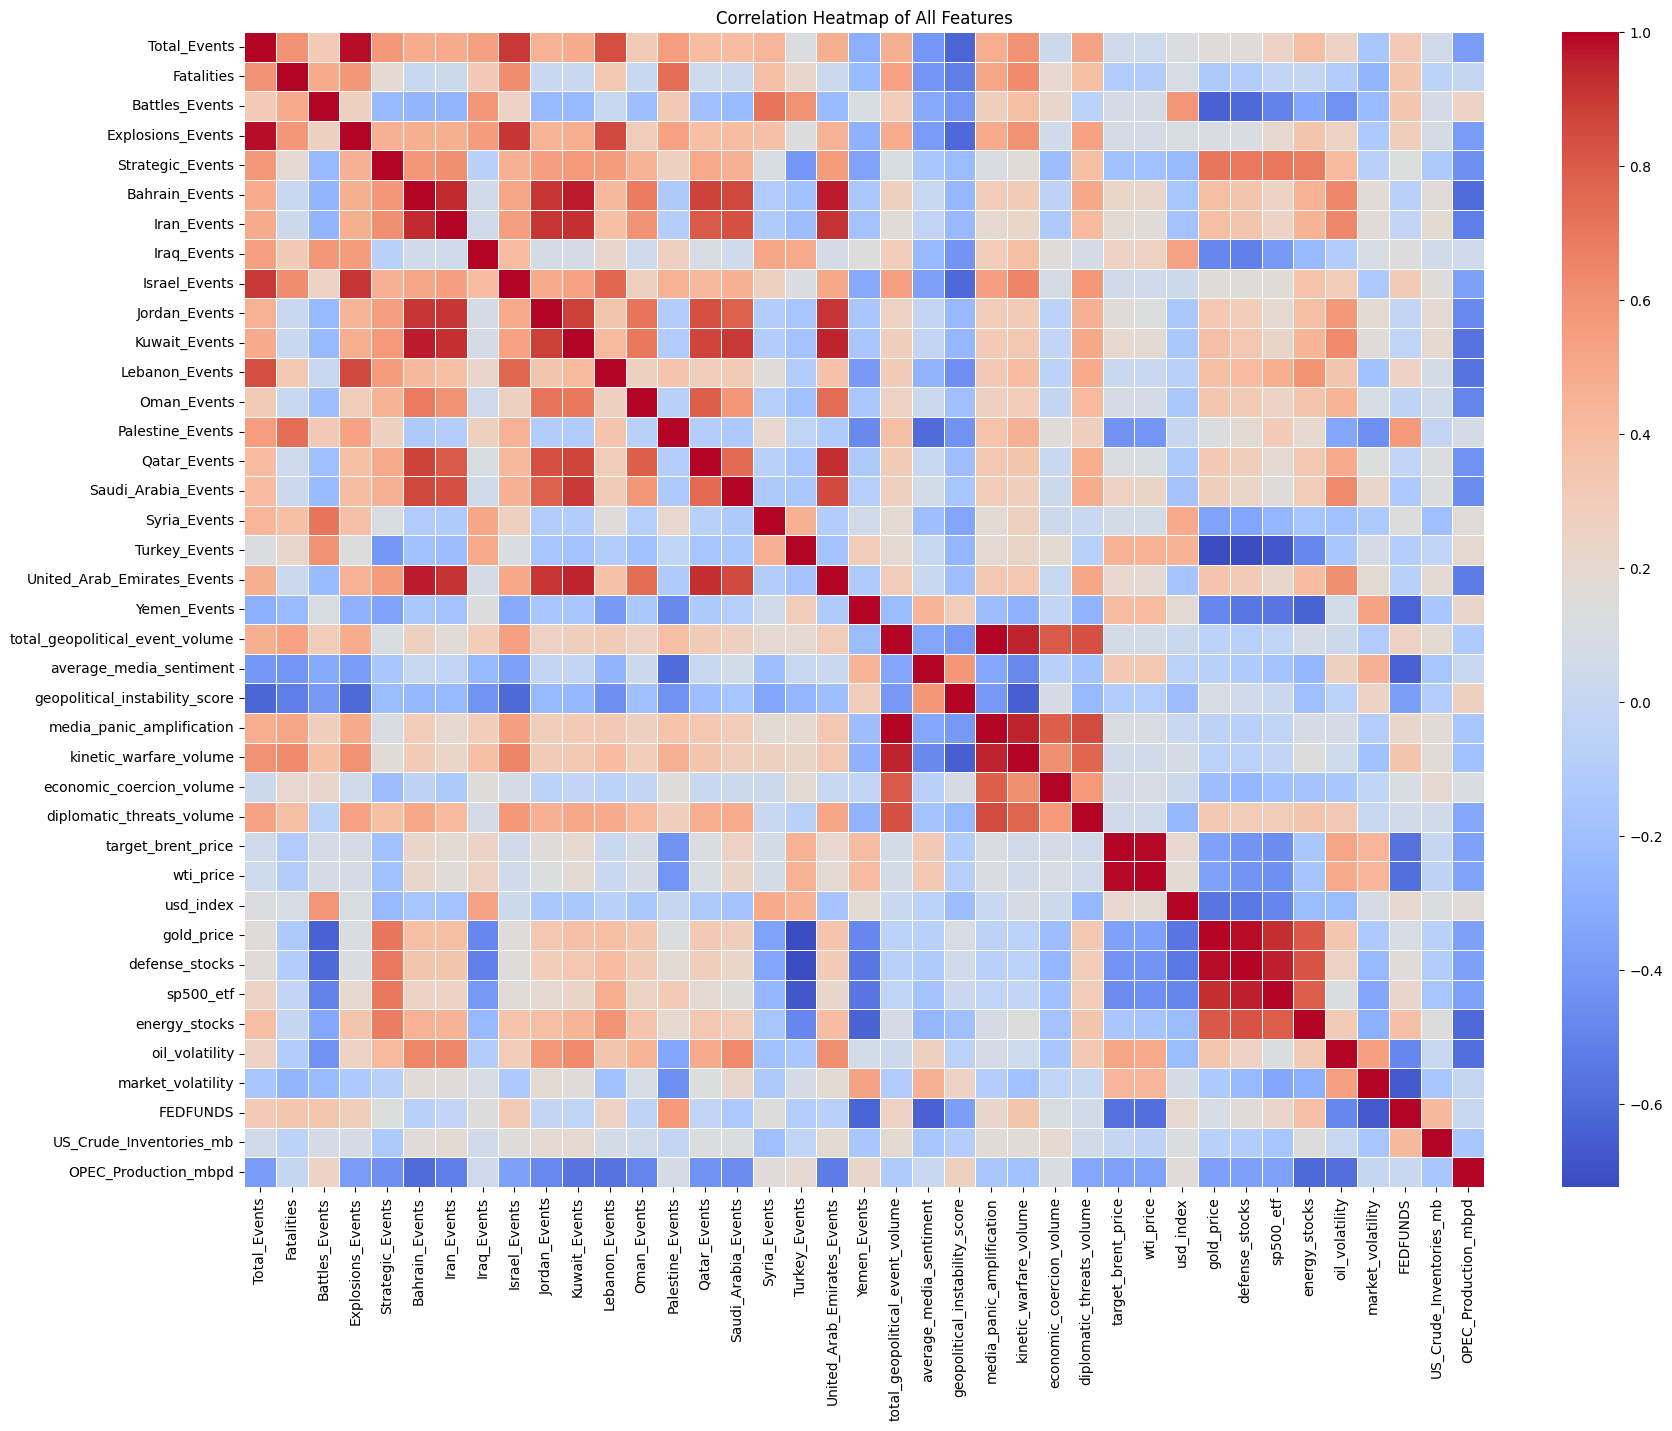

In [ ]:
# Calculate the correlation matrix
# We drop 'week_start' as it is a date and not a numeric value
corr_matrix = df.drop(columns=['week_start']).corr()

# Set up the matplotlib figure
plt.figure(figsize=(20, 15))

# Draw the heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap of All Features')
plt.show()

In [ ]:
# Drop redundant and low-correlation features
columns_to_drop = [
    'wti_price',
    'Total_Events',
    'total_geopolitical_event_volume',
    'FEDFUNDS',
    'OPEC_Production_mbpd'
]
df.drop(columns=columns_to_drop, inplace=True)

# Merge Israel and Jordan and Palestine and Lebanon events
df['Lebanon_Palestien_Jordan_Israel_Events'] = df['Lebanon_Events'] + df['Palestine_Events'] + df['Jordan_Events'] + df['Israel_Events']
df.drop(columns=['Lebanon_Events','Palestine_Events','Jordan_Events', 'Israel_Events'], inplace=True)

# Merge Turkey and Syria events
df['Turkey_And_Syria_Events'] = df['Turkey_Events'] + df['Syria_Events']
df.drop(columns=['Turkey_Events', 'Syria_Events'], inplace=True)

print(f"New shape of dataframe: {df.shape}")
print("Remaining columns:")
display(df.columns.tolist())
display(df.head())

New shape of dataframe: (236, 31)
Remaining columns:


['week_start',
 'Fatalities',
 'Battles_Events',
 'Explosions_Events',
 'Strategic_Events',
 'Bahrain_Events',
 'Iran_Events',
 'Iraq_Events',
 'Kuwait_Events',
 'Oman_Events',
 'Qatar_Events',
 'Saudi_Arabia_Events',
 'United_Arab_Emirates_Events',
 'Yemen_Events',
 'average_media_sentiment',
 'geopolitical_instability_score',
 'media_panic_amplification',
 'kinetic_warfare_volume',
 'economic_coercion_volume',
 'diplomatic_threats_volume',
 'target_brent_price',
 'usd_index',
 'gold_price',
 'defense_stocks',
 'sp500_etf',
 'energy_stocks',
 'oil_volatility',
 'market_volatility',
 'US_Crude_Inventories_mb',
 'Lebanon_Palestien_Jordan_Israel_Events',
 'Turkey_And_Syria_Events']

,week_start,Fatalities,Battles_Events,Explosions_Events,Strategic_Events,Bahrain_Events,Iran_Events,Iraq_Events,Kuwait_Events,Oman_Events,...,usd_index,gold_price,defense_stocks,sp500_etf,energy_stocks,oil_volatility,market_volatility,US_Crude_Inventories_mb,Lebanon_Palestien_Jordan_Israel_Events,Turkey_And_Syria_Events
0,2022-01-01,454,93,296,125,0,3,75,0,0,...,96.142000,1804.739990,101.616533,443.675336,25.423856,39.080000,18.322,415574.5,68,188
1,2022-01-08,468,95,363,112,0,2,96,0,0,...,95.314000,1816.379980,102.938904,439.508984,26.946074,36.928001,18.986,413813.0,53,226
2,2022-01-15,740,97,281,94,0,0,52,0,0,...,95.655001,1832.425018,100.821365,421.759918,27.268082,42.187500,25.270,416190.0,40,158
3,2022-01-22,617,154,260,98,0,0,74,0,1,...,96.577998,1820.500000,97.312057,410.406329,27.770855,47.156001,30.234,415143.0,38,204
4,2022-01-29,553,96,267,116,3,1,77,0,0,...,95.946001,1802.819995,98.532274,424.450476,29.010172,42.310001,23.290,412765.0,46,172


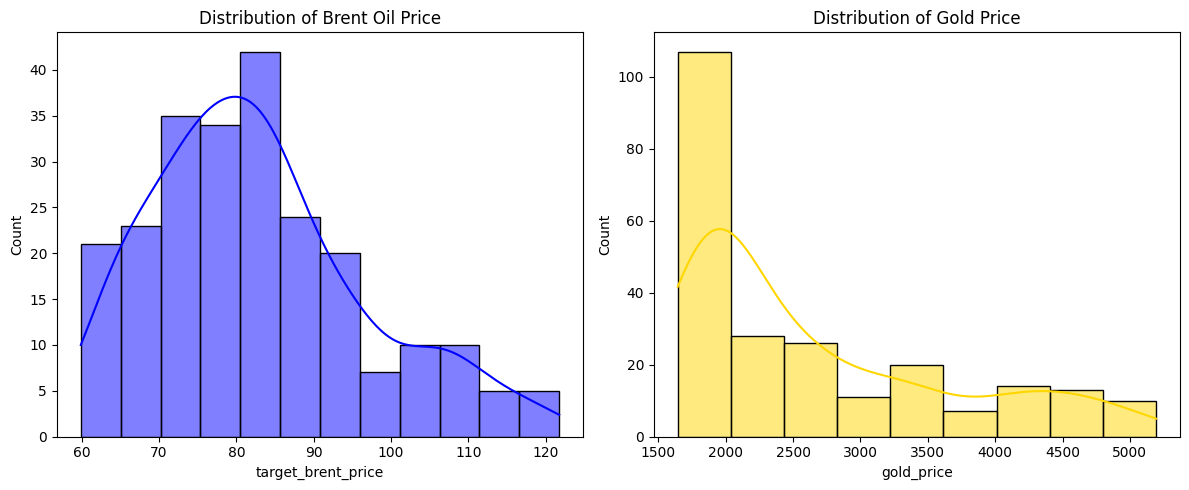

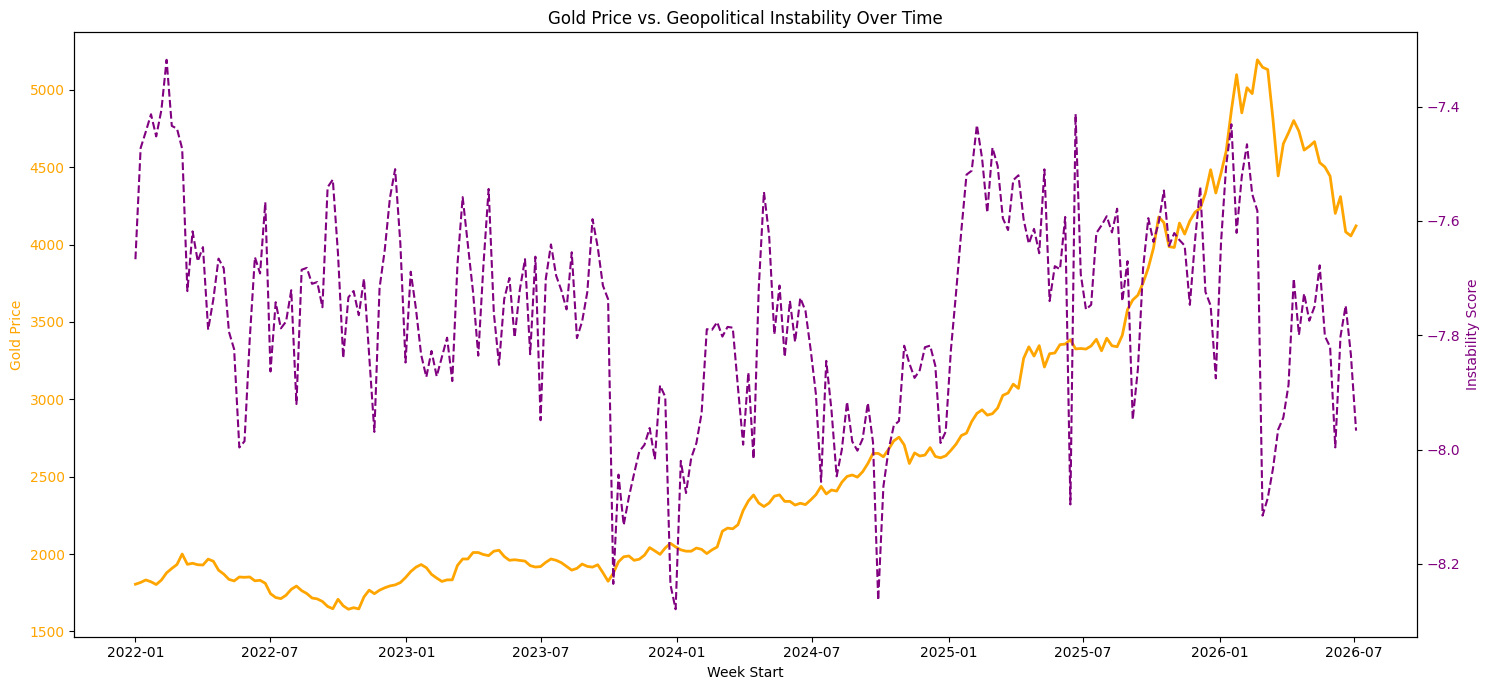

In [ ]:
# More drawings to inspect data

# Histogram
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['target_brent_price'], kde=True, color='blue')
plt.title('Distribution of Brent Oil Price')

plt.subplot(1, 2, 2)
sns.histplot(df['gold_price'], kde=True, color='gold')
plt.title('Distribution of Gold Price')

plt.tight_layout()
plt.show()

#-----

#Time series for gold vs political instability

fig, ax1 = plt.subplots(figsize=(15, 7))

# Plotting Gold Price on the primary y-axis
ax1.set_xlabel('Week Start')
ax1.set_ylabel('Gold Price', color='orange')
ax1.plot(df['week_start'], df['gold_price'], color='orange', label='Gold Price', linewidth=2)
ax1.tick_params(axis='y', labelcolor='orange')

# Creating a secondary y-axis for Geopolitical Instability
ax2 = ax1.twinx()
ax2.set_ylabel('Instability Score', color='purple')
ax2.plot(df['week_start'], df['geopolitical_instability_score'], color='purple', linestyle='--', label='Instability Score')
ax2.tick_params(axis='y', labelcolor='purple')

plt.title('Gold Price vs. Geopolitical Instability Over Time')
fig.tight_layout()
plt.show()

## Now we begin classification to improve predictions: StandScaler + K-Means clustering

In [ ]:
# the only goal to classify a label

war_features = [
    "Fatalities",
    "Battles_Events",
    "Explosions_Events",
    "Strategic_Events"
]

X_war = df[war_features].copy()

war_scaler = StandardScaler()
X_war_scaled = war_scaler.fit_transform(X_war)

kmeans_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["War_Cluster"] = kmeans_model.fit_predict(X_war_scaled)

cluster_severity = (
    df.groupby("War_Cluster")[war_features]
       .mean()
       .sum(axis=1)
       .sort_values()
)

cluster_order = cluster_severity.index.tolist()

cluster_labels = {
    cluster_order[0]: "Low",
    cluster_order[1]: "Medium",
    cluster_order[2]: "High"
}

df["War_Intensity"] = df["War_Cluster"].map(cluster_labels)

intensity_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

df["War_Intensity_Code"] = (
    df["War_Intensity"].map(intensity_map)
)

df["week_start"] = pd.to_datetime(df["week_start"])

df = (
    df.sort_values("week_start")
       .reset_index(drop=True)
)

df["War_Intensity_Lag1"] = (
    df["War_Intensity_Code"].shift(1)
)

print(
    df[
        [
            "week_start",
            "War_Intensity",
            "War_Intensity_Code",
            "War_Intensity_Lag1"
        ]
    ].head(10)
)

  week_start War_Intensity  War_Intensity_Code  War_Intensity_Lag1
0 2022-01-01           Low                   0                 NaN
1 2022-01-08           Low                   0                 0.0
2 2022-01-15           Low                   0                 0.0
3 2022-01-22           Low                   0                 0.0
4 2022-01-29           Low                   0                 0.0
5 2022-02-05           Low                   0                 0.0
6 2022-02-12           Low                   0                 0.0
7 2022-02-19           Low                   0                 0.0
8 2022-02-26           Low                   0                 0.0
9 2022-03-05           Low                   0                 0.0


In [ ]:
df['Gold_Lag_1'] = df['gold_price'].shift(1)
df['Gold_Lag_2'] = df['gold_price'].shift(2)
df['Gold_Lag_4'] = df['gold_price'].shift(4)

df_gold = df.dropna(
    subset=[
        "gold_price",
        "Gold_Lag_1",
        "Gold_Lag_2",
        "Gold_Lag_4",
        "War_Intensity_Lag1"
    ]
).copy()

gold_features = [
    "Gold_Lag_1",
    "Gold_Lag_2",
    "Gold_Lag_4",
    "War_Intensity_Lag1",
    "usd_index",
    "defense_stocks",
    "sp500_etf",
    "energy_stocks",
    "oil_volatility",
    "market_volatility",
    "US_Crude_Inventories_mb"
]

X = df_gold[gold_features]
y = df_gold["gold_price"]


#splitting for time series to only look at past

split = int(len(df_gold) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]


## ** First Model : Gold Price with Ridge Regression**

MAE  : 163.506
RMSE : 202.530
R²   : 0.808


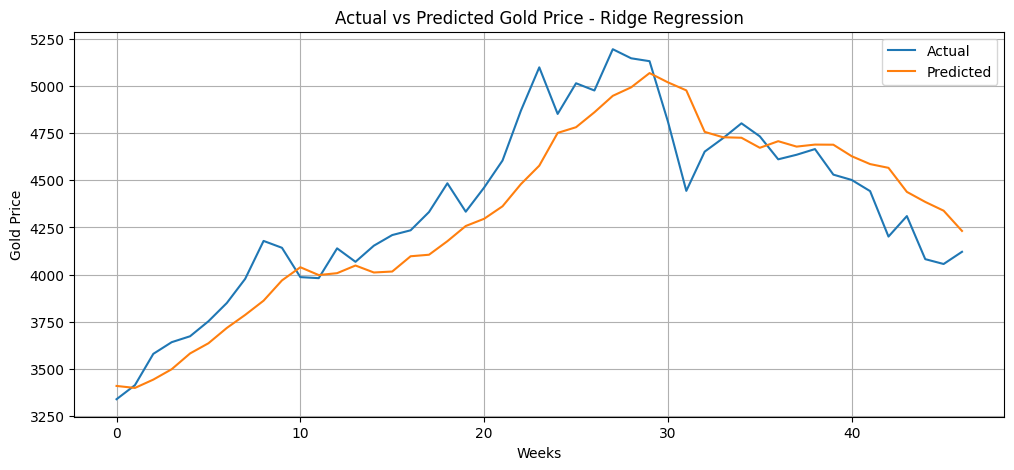

In [ ]:
model_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=10))
])

model_ridge.fit(X_train, y_train)

y_pred_ridge = model_ridge.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_ridge)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2 = r2_score(y_test, y_pred_ridge)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")


plt.figure(figsize=(12, 5))

plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_ridge, label='Predicted')

plt.title('Actual vs Predicted Gold Price - Ridge Regression')
plt.xlabel('Weeks')
plt.ylabel('Gold Price')

plt.legend()
plt.grid(True)
plt.show()

## ** Second Model : Oil Price with Random Forest **

Random Forest - Brent Oil Price Prediction
MAE  : 4.863
RMSE : 6.007
R²   : 0.874


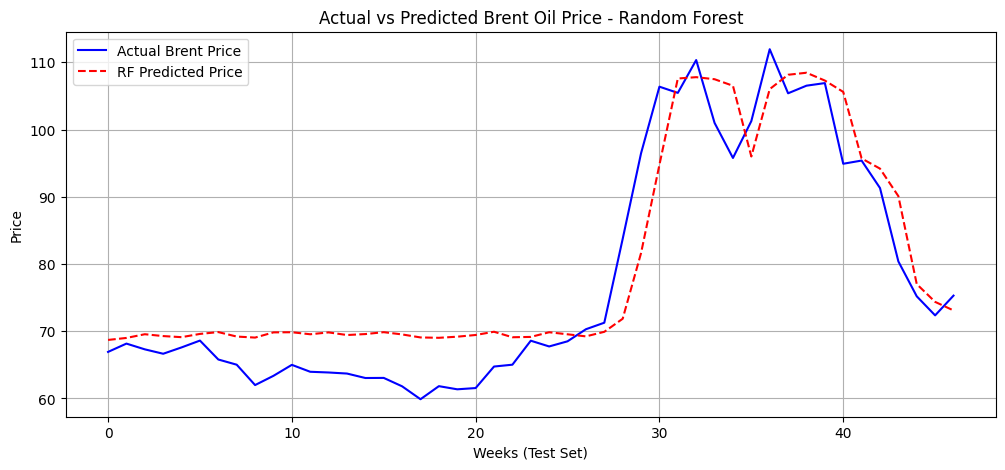

In [ ]:
# Feature engineering for Oil Price prediction
df['Brent_Lag_1'] = df['target_brent_price'].shift(1)
df['Brent_Lag_2'] = df['target_brent_price'].shift(2)

# Prepare features and target
oil_features = [
    "Brent_Lag_1",
    "Brent_Lag_2",
    "War_Intensity_Lag1",
    "usd_index",
    "defense_stocks",
    "sp500_etf",
    "energy_stocks",
    "oil_volatility",
    "market_volatility",
    "US_Crude_Inventories_mb"
]

# Drop rows with NaNs created by lagging
df_oil = df.dropna(subset=oil_features + ['target_brent_price']).copy()

X_oil = df_oil[oil_features]
y_oil = df_oil['target_brent_price']

# Time-series split (80/20)
split_idx = int(len(df_oil) * 0.8)
X_train_oil, X_test_oil = X_oil.iloc[:split_idx], X_oil.iloc[split_idx:]
y_train_oil, y_test_oil = y_oil.iloc[:split_idx], y_oil.iloc[split_idx:]

# Initialize and train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_oil, y_train_oil)

# Predictions
y_pred_rf = rf_model.predict(X_test_oil)

# Evaluation
mae_rf = mean_absolute_error(y_test_oil, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_oil, y_pred_rf))
r2_rf = r2_score(y_test_oil, y_pred_rf)

print(f"Random Forest - Brent Oil Price Prediction")
print(f"MAE  : {mae_rf:.3f}")
print(f"RMSE : {rmse_rf:.3f}")
print(f"R²   : {r2_rf:.3f}")

# Visualization
plt.figure(figsize=(12, 5))
plt.plot(y_test_oil.values, label='Actual Brent Price', color='blue')
plt.plot(y_pred_rf, label='RF Predicted Price', color='red', linestyle='--')
plt.title('Actual vs Predicted Brent Oil Price - Random Forest')
plt.xlabel('Weeks (Test Set)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()